In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')

In [2]:
info_mpmt = f"../results_files_ML/mPMT_HAWCSim_array/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_train_dist_0000_0700m_13pe/test_dist_0000_0700m_13pe/0.5val_legend_info.txt"
roc_points_mpmt = f"../results_files_ML/mPMT_HAWCSim_array/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_train_dist_0000_0700m_13pe/test_dist_0000_0700m_13pe/0.5val_roc_points.txt"
info_8inches = f"../results_files_ML/8inches_HAWCSim_array/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_train_dist_0000_0700m_13pe/test_dist_0000_0700m_13pe/0.5val_legend_info.txt"
roc_points_8inches = f"../results_files_ML/8inches_HAWCSim_array/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_train_dist_0000_0700m_13pe/test_dist_0000_0700m_13pe/0.5val_roc_points.txt"

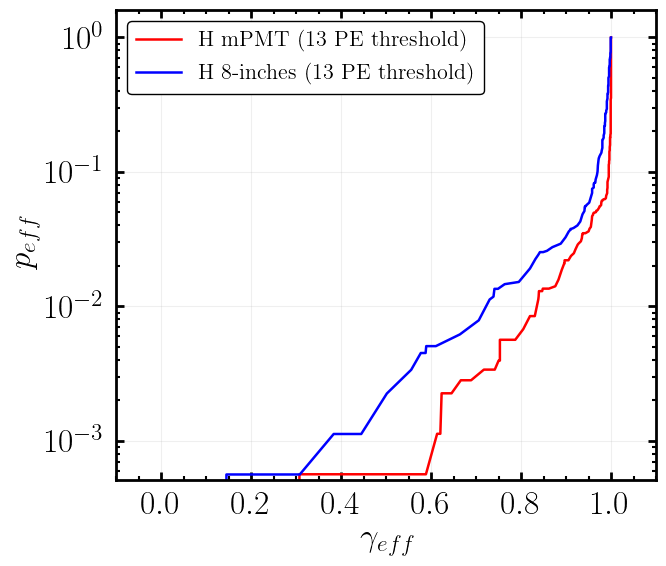

In [3]:
import numpy as np
import matplotlib.pyplot as plt

info_mpmt = (
    "../results_files_ML/mPMT_HAWCSim_array/"
    "100300TeV_030deg_4FF_180R175h_Black/"
    "XGB_IC_train_dist_0000_0700m_13pe/"
    "test_dist_0000_0700m_13pe/"
    "0.5val_legend_info.txt"
)

roc_points_mpmt = (
    "../results_files_ML/mPMT_HAWCSim_array/"
    "100300TeV_030deg_4FF_180R175h_Black/"
    "XGB_IC_train_dist_0000_0700m_13pe/"
    "test_dist_0000_0700m_13pe/"
    "0.5val_roc_points.txt"
)

info_8inches = (
    "../results_files_ML/8inches_HAWCSim_array/"
    "100300TeV_030deg_4FF_180R175h_Black/"
    "XGB_IC_train_dist_0000_0700m_13pe/"
    "test_dist_0000_0700m_13pe/"
    "0.5val_legend_info.txt"
)

roc_points_8inches = (
    "../results_files_ML/8inches_HAWCSim_array/"
    "100300TeV_030deg_4FF_180R175h_Black/"
    "XGB_IC_train_dist_0000_0700m_13pe/"
    "test_dist_0000_0700m_13pe/"
    "0.5val_roc_points.txt"
)


# Load ROC points:
tpr_mpmt, fpr_mpmt = np.loadtxt(
    roc_points_mpmt,
    comments="#",
    usecols=(4, 5),
    unpack=True
)

tpr_8inches, fpr_8inches = np.loadtxt(
    roc_points_8inches,
    comments="#",
    usecols=(4, 5),
    unpack=True
)


fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    tpr_mpmt,
    fpr_mpmt,
    color="red",
    lw=1.8,
    ls="-",
    label="H mPMT (13 PE threshold)"
)

ax.plot(
    tpr_8inches,
    fpr_8inches,
    color="blue",
    lw=1.8,
    ls="-",
    label="H 8-inches (13 PE threshold)"
)

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.minorticks_on()

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=2,
    labelsize=24
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.5
)
ax.set_xlabel(r"$\gamma_{eff}$", fontsize=24)
ax.set_ylabel(r"$p_{eff}$", fontsize=24)

ax.set_yscale("log")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.51e-3, 1.6)

ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1.00])

ax.grid(True, alpha=0.2)

ax.legend(
    fontsize=16,
    edgecolor="black",
    facecolor="white",
    framealpha=1.0,
    loc="upper left"
)

plt.savefig("../pictures/Comparison_Plots/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/roc_curve_mPMT_vs_8inches.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3044098/3893369792.py:3: RuntimeWarning: divide by zero encountered in divide
  SNR_mpmt = tpr_mpmt/np.sqrt(fpr_mpmt)
/tmp/ipykernel_3044098/3893369792.py:6: RuntimeWarning: divide by zero encountered in divide
  SNR_8inches = tpr_8inches/np.sqrt(fpr_8inches)


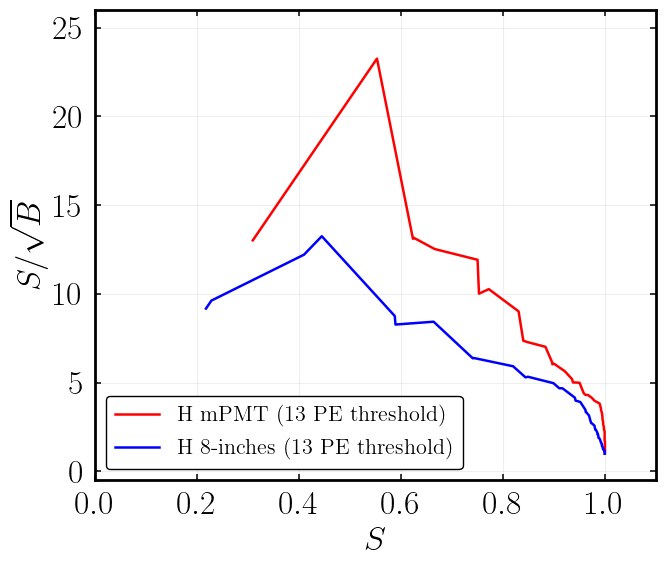

In [4]:
step = 4

SNR_mpmt = tpr_mpmt/np.sqrt(fpr_mpmt)
S_mpmt = tpr_mpmt

SNR_8inches = tpr_8inches/np.sqrt(fpr_8inches)
S_8inches = tpr_8inches

for spine in ax.spines.values():
    spine.set_linewidth(2)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(S_mpmt[::step], SNR_mpmt[::step], color="red", lw=1.8, ls="-", label="H mPMT (13 PE threshold)")

ax.plot(S_8inches[::step], SNR_8inches[::step], color="blue", lw=1.8, ls="-", label="H 8-inches (13 PE threshold)")

ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$S$", fontsize=24)
ax.set_ylabel(r"$S/\sqrt{B}$", fontsize=24)

# limits
ax.set_xlim(0, 1.1)
ax.set_ylim(-0.5, 26)


# grid (subtle)
ax.grid(True, alpha=0.2)

# optional: clean x ticks like before
ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1.0])

for spine in ax.spines.values():
    spine.set_linewidth(2) 

ax.legend(
    fontsize=16,
    edgecolor="black",
    facecolor="white",
    framealpha=1.0,
    loc="lower left"
)

plt.savefig("../pictures/Comparison_Plots/100300TeV_030deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/SNR_curve_mPMT_vs_8inches.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()